# Chapter 9: Searching the Future

A controller can spend its planning budget exploring every continuation or use a heuristic to focus on promising routes. The heuristic buys speed by estimating remaining cost. If it exaggerates the wrong route's cost, the search can stop at a more expensive goal while a cheaper possibility waits in the queue.

This notebook exposes both the search trace and a full-graph audit. A* uses the supplied heuristic; a separate reverse shortest-path computation establishes the true remaining costs inside this finite graph. The diagnostic can therefore distinguish helpful guidance from misleading confidence. It also accounts for heuristic evaluations, because computing a clever estimate is not free merely because the path chart omits that expense.

**Outcome:** Execute A* and audit supplied heuristic admissibility and cost.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

A\* orders queued states by f(n)=g(n)+h(n), where g is the best discovered path cost from the start and h estimates remaining cost. An admissible heuristic satisfies h(n)<=d\*(n,goal). A consistent heuristic satisfies h(u)<=c(u,v)+h(v) for every edge and h(goal)=0.

With nonnegative costs and an admissible heuristic, a search that reopens improved states can stop when the goal is popped and recover an optimal path. The chapter's worked graphs assume strictly positive edge costs; this finite-graph implementation also accepts zero-cost edges. That is a deliberate, valid widening: a state is queued again only when its g strictly improves, so the search terminates on a finite graph even with zero-cost cycles, and with an admissible heuristic the first popped goal is still optimal. The chapter's statements that rely on a positive-cost step are not claimed for zero-cost edges. Consistency is a stronger local condition that simplifies the behavior of expanded states. The implementation permits reopening by inserting a state again whenever its best g improves; obsolete queue entries are skipped.

The audit computes exact remaining costs using Dijkstra's algorithm on reversed edges. This is feasible because the teaching graph is fully known. It does not mean a deployed search gets an optimal heuristic for free. Path cost, expansion count, and declared heuristic expense are separate metrics with separate units. A faster search can still consume more total compute if each heuristic call is expensive.

## Apply this to an agent

Represent the agent's candidate plans as routes with explicit costs. Check whether a heuristic can overlook a cheaper plan, and include the cost of computing the heuristic. A good-looking estimate is not a certificate of admissibility.

## A calculation you can run

Register nodes and nonnegative weighted directed edges. Give every node a finite nonnegative heuristic. The function first calculates exact graph distances for diagnostic comparison, then runs A* using the supplied values. It records each expanded node's g and f, reconstructs the first popped goal path, and counts heuristic calls.

The plot shows the g cost of successive expansions. It is a search-order trace, not a monotonic convergence curve. Consult the returned path cost and exact optimal cost together. In the changed case only B's heuristic rises. Predict which goal will be popped first and whether the admissibility check will pass. Keep the separate heuristic-total-cost metric when comparing implementations.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 9
inputs = {'nodes': ['S', 'A', 'B', 'G'],
 'start': 'S',
 'goal': 'G',
 'edges': [{'from': 'S', 'to': 'A', 'cost': 1},
           {'from': 'A', 'to': 'G', 'cost': 4},
           {'from': 'S', 'to': 'B', 'cost': 2},
           {'from': 'B', 'to': 'G', 'cost': 1}],
 'heuristic': {'S': 3, 'A': 4, 'B': 1, 'G': 0},
 'heuristic_cost': 0.1}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: constructed teaching example

Calculated quantities:
{
  "path": [
    "S",
    "B",
    "G"
  ],
  "path_cost": 3.0,
  "optimal_cost": 3.0,
  "admissible": true,
  "consistent": true,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.4
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


The default shortest route is S,B,G with cost 2+1=3. The heuristic matches true remaining distances and is both admissible and consistent. A* expands toward B and reaches the cheaper goal.

In the changed case h(B)=10 exceeds B's true remaining cost 1. The A branch looks cheaper to the queue, so the first popped goal follows S,A,G and costs 5. The exact graph optimum remains 3. The algorithm has not disproved A*; the supplied heuristic violated the condition needed for its optimality guarantee. The audit makes that violation visible beside the result.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


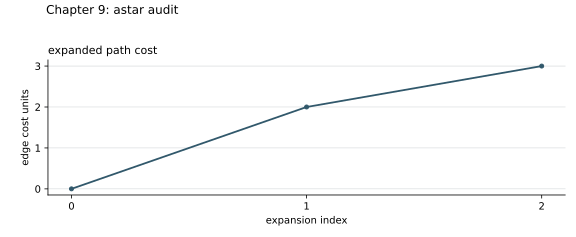

In [3]:
display(SVG(figure_svg(report)))

**Figure 9.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

An inadmissible heuristic can still return an optimal path on some graphs. That coincidence does not validate its contract. Conversely, a zero heuristic can be perfectly valid while offering no guidance beyond uniform-cost search. Evaluate correctness conditions separately from observed expansion savings.

The full-graph diagnostic itself has a cost and requires knowledge that may not exist in an open-ended planning problem. Do not claim the audit certifies an unknown environment. Its scope is the supplied finite graph and its declared edges.

A path can also be cheaper in edge units while more expensive in wall time, authority, or tool use. If those quantities matter, encode a justified cost model or report them separately. Adding incompatible units into one number without a valuation rule makes an apparently optimal path meaningless.

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "path": [
    "S",
    "A",
    "G"
  ],
  "path_cost": 5.0,
  "optimal_cost": 3.0,
  "admissible": false,
  "consistent": false,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.4
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


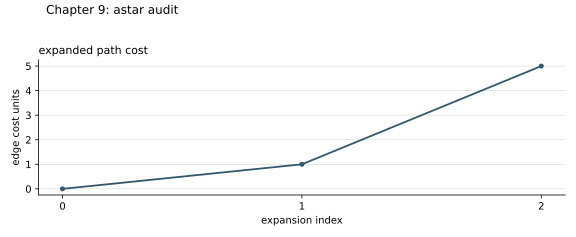

In [4]:
changed_inputs = {'nodes': ['S', 'A', 'B', 'G'],
 'start': 'S',
 'goal': 'G',
 'edges': [{'from': 'S', 'to': 'A', 'cost': 1},
           {'from': 'A', 'to': 'G', 'cost': 4},
           {'from': 'S', 'to': 'B', 'cost': 2},
           {'from': 'B', 'to': 'G', 'cost': 1}],
 'heuristic': {'S': 3, 'A': 4, 'B': 10, 'G': 0},
 'heuristic_cost': 0.1}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 9.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer graph uses a zero heuristic. A* becomes uniform-cost search and finds source,middle,target with cost 4 instead of the direct cost 7. This is a useful baseline: correctness does not depend on a sophisticated heuristic.

For reader data, preserve directed costs and distinguish unavailable edges from expensive edges. If you propose a heuristic, explain why it is a lower bound or label it as an unguaranteed guide. Compare its returned path with a small exact case and account for computation expense. Use graph reachability first when the main question is permission rather than cheapest continuation.

In [5]:
transfer_inputs = {'nodes': ['source', 'middle', 'target'],
 'start': 'source',
 'goal': 'target',
 'edges': [{'from': 'source', 'to': 'middle', 'cost': 2},
           {'from': 'middle', 'to': 'target', 'cost': 2},
           {'from': 'source', 'to': 'target', 'cost': 7}],
 'heuristic': {'source': 0, 'middle': 0, 'target': 0},
 'heuristic_cost': 0}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: constructed transfer example

Calculated quantities:
{
  "path": [
    "source",
    "middle",
    "target"
  ],
  "path_cost": 4.0,
  "optimal_cost": 4.0,
  "admissible": true,
  "consistent": true,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.0
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **nodes:** Unique graph identifiers.
- **start:** Registered search start.
- **goal:** Registered goal.
- **edges:** Directed from/to identifiers with finite nonnegative cost.
- **heuristic:** Object mapping each node to a nonnegative estimated remaining cost.
- **heuristic_cost:** Nonnegative declared cost of one heuristic evaluation, separate from path cost.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch09.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 9: astar-audit
Does this heuristic help search without hiding a cheaper route?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "path": [
    "source",
    "middle",
    "target"
  ],
  "path_cost": 4.0,
  "optimal_cost": 4.0,
  "admissible": true,
  "consistent": true,
  "expansions": 3,
  "heuristic_calls": 4,
  "heuristic_total_cost": 0.0
}

Interpretation:
A* stops at the first popped goal and reopens improved states. The exact reverse shortest-path check detects misleading supplied heuristics.

Assumptions:
- Finite graph with nonnegative edge costs.
- Heuristic costs are separate from path costs.

Limitations:
- An inadmissible heuristic can return a suboptimal goal.
- Full-graph heuristic auditing can cost more than the search itself.

Execution: completed locally; constructed inputs are not deployment measurements.


## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c09-d01"></a>

### Demonstration 1: Following the search one selection at a time

What does the search record, select and update at each step, and where does a recorded cost get corrected?

![Equation 9.2](../assets/math/c87fd983fba2133d2416.svg)

**Symbols and units:** g-hat(v) is the cost of the cheapest path to vertex v that the search has found so far (navy), h-hat(v) is the estimate of the cost still to come (hatched), and f-hat(v) their sum, the queue score. A selection removes the entry with the smallest score (ties: smaller g-hat, then label); an expansion generates its successors. A successor is updated only when an edge gives it a strictly lower cost. The three traces are the chapter's: four vertices with edge costs 3, 7, 2 and 3 (vertex B taken as the goal); the two-route graph with a zero estimate; and the research workflow with estimates 2, 1, 1, 0 (search 1 s, fetch 2 s, verify 4 s).

Each step removes the cheapest queue entry and either stops at a goal or generates successors. The recorded cost only ever moves down toward the true cheapest cost, so that half of Equation (9.2) is bookkeeping; the estimate is the half that needs knowledge from outside. In the research workflow every action taken at the wrong stage is a self-loop with a higher cost for the same state, and the strict improvement rule discards it, so the frontier holds one useful state at a time.

**Use in this chapter:** When an agent reaches the same state by two sequences of tool calls, keep one best cost for that state and update it only when a strictly cheaper sequence appears. The record is then a trustworthy upper bound.

**Assumptions:** Edge costs are fixed, known and positive, and a repeated vertex is the same state however it was reached. That fails when the cost of a step depends on the history, for example a deadline or a tool whose price changes with use. The bookkeeping graph names no goal in the chapter; B is taken as the goal here so that the trace ends.

**Predict before running:** In the four-vertex trace, after A is expanded, does B's recorded cost stay at 7?

**Controls you can change:**

- **Trace:** `trace` accepts 'fig91', 'zero', 'flow'.
- **Selection:** `step` accepts 1, 2, 3, 4.

**Source section:** The trace, worked.

**Evidence:** constructed teaching example.

Constructed example: the chapter's four-vertex trace (edge costs 3, 7, 2 and 3, where 7 becomes 6), its two-route zero-estimate table and its research workflow (costs 1, 2, 4; estimates 2, 1, 1, 0), each checked against the laboratory's A* function.

Prediction choices:

1. Yes, 7 is the first cost found
2. No, it falls to 6
3. No, it rises to 8

**Boundary of the conclusion:** The worked guarantees here assume fixed, known positive edge costs. An agent can sometimes construct such a model, but uncertain latency or history-dependent costs require additional modeling.

**Common wrong turn:** The chapter separates the two halves. The recorded cost is a record of work done: it can only be too high, and it falls when a cheaper route turns up (7 becomes 6). The guess about what remains lives in the estimate.

Following the search one selection at a time
Controls: {"trace": "fig91", "step": 1}
Evidence: constructed teaching example

Calculated quantities:
Selected: s
Recorded cost g, score f: 0, 0
Expanded so far: s
Edges examined so far: 2
Frontier, next first: A (3), B (7)

Worked steps:
1. Select s: f = 0 + 0 = 0.
2. A gets g = 0 + 3 = 3 and f = 3 + 0 = 3.
3. B gets g = 0 + 7 = 7 and f = 7 + 0 = 7.
4. Frontier, next first: A 3, B 7.

Select s: f = 0 + 0 = 0. A gets g = 0 + 3 = 3 and f = 3 + 0 = 3. B gets g = 0 + 7 = 7 and f = 7 + 0 = 7.

Assumptions: Edge costs are fixed, known and positive, and a repeated vertex is the same state however it was reached. That fails when the cost of a step depends on the history, for example a deadline or a tool whose price changes with use. The bookkeeping graph names no goal in the chapter; B is taken as the goal here so that the trace ends.
Source section: The trace, worked
Provenance: Constructed example: the chapter's four-vertex trace (edge costs 3, 

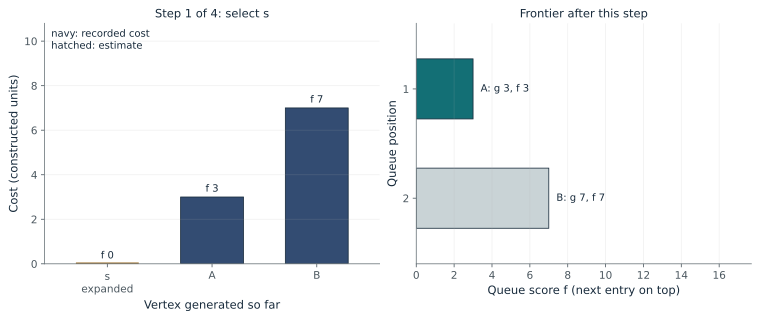

In [8]:
demo_id = 'C09-D01'
demo_controls = {'trace': 'fig91', 'step': 1}
demo_result = run_demo(9, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Trace** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Following the search one selection at a time
Controls: {"trace": "zero", "step": 1}
Evidence: constructed teaching example

Calculated quantities:
Selected: s
Recorded cost g, score f: 0, 0
Expanded so far: s
Edges examined so far: 2
Frontier, next first: a (1), b (1)

Worked steps:
1. Select s: f = 0 + 0 = 0.
2. a gets g = 0 + 1 = 1 and f = 1 + 0 = 1.
3. b gets g = 0 + 1 = 1 and f = 1 + 0 = 1.
4. Frontier, next first: a 1, b 1.

Select s: f = 0 + 0 = 0. a gets g = 0 + 1 = 1 and f = 1 + 0 = 1. b gets g = 0 + 1 = 1 and f = 1 + 0 = 1.

Assumptions: Edge costs are fixed, known and positive, and a repeated vertex is the same state however it was reached. That fails when the cost of a step depends on the history, for example a deadline or a tool whose price changes with use. The bookkeeping graph names no goal in the chapter; B is taken as the goal here so that the trace ends.
Source section: The trace, worked
Provenance: Constructed example: the chapter's four-vertex trace (edge costs 3, 7

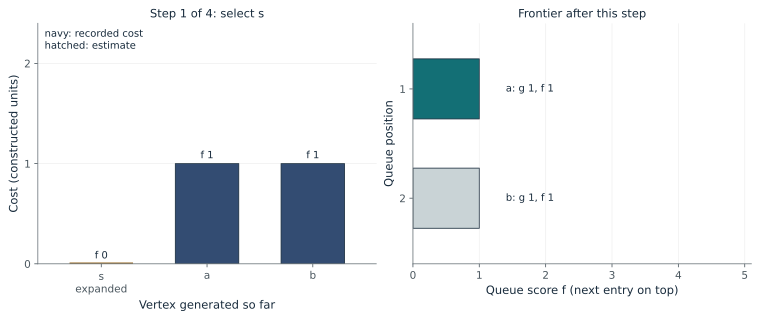

In [9]:
changed_controls = {'trace': 'zero', 'step': 1}
changed_demo = run_demo(9, 'C09-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(9, 'C09-D01'):
    state = run_demo(9, 'C09-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "trace": "fig91",
      "step": 1
    },
    "metrics": [
      [
        "Selected",
        "s"
      ],
      [
        "Recorded cost g, score f",
        "0, 0"
      ],
      [
        "Expanded so far",
        "s"
      ],
      [
        "Edges examined so far",
        "2"
      ],
      [
        "Frontier, next first",
        "A (3), B (7)"
      ]
    ]
  },
  {
    "controls": {
      "trace": "fig91",
      "step": 2
    },
    "metrics": [
      [
        "Selected",
        "A"
      ],
      [
        "Recorded cost g, score f",
        "3, 3"
      ],
      [
        "Expanded so far",
        "s, A"
      ],
      [
        "Edges examined so far",
        "4"
      ],
      [
        "Frontier, next first",
        "C (5), B (6)"
      ]
    ]
  },
  {
    "controls": {
      "trace": "fig91",
      "step": 3
    },
    "metrics": [
      [
        "Selected",
        "C"
      ],
      [
        "Recorded cost g, score f",
        "5

**Check your understanding:** If the edge from A to B cost 2 and the direct edge from s to B cost 7, what would B's record become after A is expanded?

[Answer and worked reasoning](../solutions/ch09.md#demonstration-1). [Matching browser demonstration](../readers/09-astar-audit/reader.html#C09-D01).

<a id="demo-c09-d02"></a>

### Demonstration 2: One overestimate can hide the cheaper route

How far can the estimate at one vertex exceed its true remaining cost before the search returns the dearer route, and which vertices does the exact f single out?

![Equation 9.1](../assets/math/d644bc5f6d134538bbc7.svg)

![Equation 9.3](../assets/math/0363a1925aa679905892.svg)

**Symbols and units:** g(v) is the cost of the best path from the start to v and h(v) the cost of the best path from v onward to a goal, so f(v) = g(v) + h(v) is the cost of the best route forced through v. h-hat(v) is the estimate. A queue score is cost so far plus estimate and the search removes the smallest first. The cases: the chapter's two-route graph (costs 1, 9, 1, 24; true remaining costs 9 at a and 24 at b), the notebook graph (S to A 1, A to G 4, S to B 2, B to G 1; true remaining cost 1 at B), and the notebook's transfer graph (2, 2 and a direct 7; true remaining cost 2 at the middle vertex). The estimate level is applied to the cheap route's first vertex.

A vertex is expanded only while its score is at or below the rival route's score. An estimate at or below the true remaining cost keeps it well inside that limit; one far above pushes it past, the rival goal is selected first and the cheap route is never examined. Between the two the condition is broken yet the best route can still come back, so the condition is a guarantee, not a symptom detector. The right panel shows Equation (9.1): f equals the optimal cost on every vertex of an optimal path and exceeds it everywhere else.

**Use in this chapter:** Before describing a search as optimal, ask whether any estimate in it can exceed the true remaining cost. One high estimate on the wrong branch is enough to lose the best route. The notebook's default and changed cases are the second and fourth levels of the notebook graph (estimates 1 and 10 at B), and its transfer case is the first level of the transfer graph.

**Assumptions:** The graphs, costs and queue rules are fixed as stated. A broken Equation (9.3) can still return the best route, as the middle levels show, and on other graphs the threshold would differ. Ties in score are broken by smaller cost so far, then by label. Only one vertex's estimate is varied; the others keep the case's values.

**Predict before running:** In the chapter's two-route graph the true remaining cost at a is 9. Set the estimate at a to its largest level, 25. Does the search return the cost-25 route?

**Controls you can change:**

- **Graph:** `case` accepts 'tworoute', 'notebook', 'transfer'.
- **Estimate at the cheap route's first vertex:** `level` accepts 0, 1, 2, 3.

**Source section:** The condition that makes it correct.

**Evidence:** constructed teaching example.

Constructed example: the chapter's two-route graph (costs 1, 9, 1, 24), the laboratory notebook's default and changed graph (heuristic at B 1 and 10) and transfer graph (zero estimates), with other estimate levels defined for this reader; every search is also run through the laboratory's A* function.

Prediction choices:

1. Yes, the cost-25 route
2. No, the cost-10 route
3. It returns nothing

**Boundary of the conclusion:** A learned predictor needs a certified uniform error bound over the relevant domain to justify claiming admissibility everywhere. Subtracting the largest overshoot in a test set bounds those observed errors only; an unseen state can exceed it.

**Common wrong turn:** The chapter says an overestimate need not cause a wrong answer on every graph; it removes the general guarantee. In the two-route graph an estimate of 20 at a still returns the cost-10 route, and only 25 loses it.

One overestimate can hide the cheaper route
Controls: {"case": "tworoute", "level": 1}
Evidence: constructed teaching example

Calculated quantities:
Score of a: g + estimate: 10
Equation (9.3) holds everywhere: yes
Vertices expanded: s, a
Generated but unexpanded: b
Route returned: cost 10 (optimal, best is 10)

Worked steps:
1. True remaining cost at a is h(a) = 9; the estimate is 9.
2. Equation (9.3): 9 <= 9 is true.
3. Score of a = 1 + 9 = 10; the rival route scores 25.
4. a is expanded (it is expanded only when its score is at most 25).
5. Route returned costs 10; the best costs 10.
6. Exact f = g + h equals C* = 10 on s, a, goal_a.

Exact f: s = 0 + 10 = 10, a = 1 + 9 = 10, b = 1 + 24 = 25, goal_a = 10 + 0 = 10, goal_b = 25 + 0 = 25. Vertices with f = C* = 10 (on an optimal path): s, a, goal_a. Score of a = 1 + 9 = 10 against the rival route's 25. The estimate at a is at or below its true remaining cost 9, so Equation (9.3) holds and the search returns cost 10, the best. Admissib

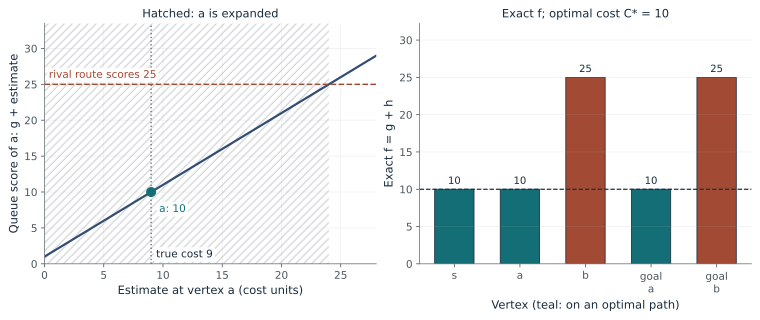

In [11]:
demo_id = 'C09-D02'
demo_controls = {'case': 'tworoute', 'level': 1}
demo_result = run_demo(9, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Graph** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

One overestimate can hide the cheaper route
Controls: {"case": "notebook", "level": 1}
Evidence: constructed teaching example

Calculated quantities:
Score of B: g + estimate: 3
Equation (9.3) holds everywhere: yes
Vertices expanded: S, B
Generated but unexpanded: A
Route returned: cost 3 (optimal, best is 3)

Worked steps:
1. True remaining cost at B is h(B) = 1; the estimate is 1.
2. Equation (9.3): 1 <= 1 is true.
3. Score of B = 2 + 1 = 3; the rival route scores 5.
4. B is expanded (it is expanded only when its score is at most 5).
5. Route returned costs 3; the best costs 3.
6. Exact f = g + h equals C* = 3 on S, B, G.

Exact f: S = 0 + 3 = 3, A = 1 + 4 = 5, B = 2 + 1 = 3, G = 3 + 0 = 3. Vertices with f = C* = 3 (on an optimal path): S, B, G. Score of B = 2 + 1 = 3 against the rival route's 5. The estimate at B is at or below its true remaining cost 1, so Equation (9.3) holds and the search returns cost 3, the best. Admissible estimates can save expansions but cannot lose the best

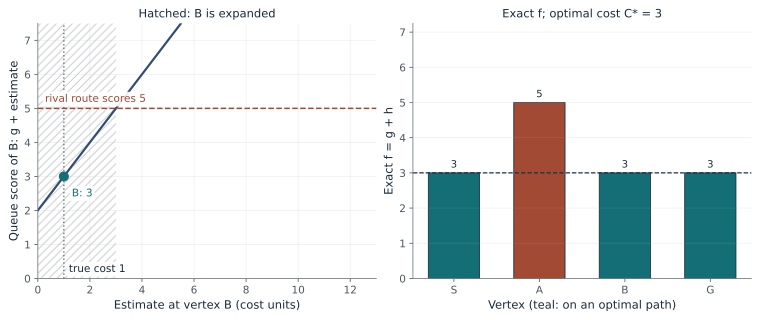

In [12]:
changed_controls = {'case': 'notebook', 'level': 1}
changed_demo = run_demo(9, 'C09-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(9, 'C09-D02'):
    state = run_demo(9, 'C09-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "tworoute",
      "level": 0
    },
    "metrics": [
      [
        "Score of a: g + estimate",
        "1"
      ],
      [
        "Equation (9.3) holds everywhere",
        "yes"
      ],
      [
        "Vertices expanded",
        "s, a"
      ],
      [
        "Generated but unexpanded",
        "b"
      ],
      [
        "Route returned",
        "cost 10 (optimal, best is 10)"
      ]
    ]
  },
  {
    "controls": {
      "case": "tworoute",
      "level": 1
    },
    "metrics": [
      [
        "Score of a: g + estimate",
        "10"
      ],
      [
        "Equation (9.3) holds everywhere",
        "yes"
      ],
      [
        "Vertices expanded",
        "s, a"
      ],
      [
        "Generated but unexpanded",
        "b"
      ],
      [
        "Route returned",
        "cost 10 (optimal, best is 10)"
      ]
    ]
  },
  {
    "controls": {
      "case": "tworoute",
      "level": 2
    },
    "metrics": [
      [
      

**Check your understanding:** In the notebook graph the rival route through A reaches G at cost 5 and B has recorded cost 2. What is the largest estimate at B that still lets B be expanded before that goal is selected?

[Answer and worked reasoning](../solutions/ch09.md#demonstration-2). [Matching browser demonstration](../readers/09-astar-audit/reader.html#C09-D02).

<a id="demo-c09-d03"></a>

### Demonstration 3: An estimate must not contradict itself

How far may the estimate fall across an edge before it breaks the consistency condition?

![Equation 9.4](../assets/math/b63e0576c12f18c007c1.svg)

![Mathematical relation](../assets/demo-equations/8e728add71dfd057546b.svg)

**Symbols and units:** u and v are neighbouring vertices joined by an edge. h-hat(u) and h-hat(v) are the estimates at each end, cost(u,v) is the edge cost, and h(u,v) is the true cheapest cost from u to v. In this fragment u is the start and each edge is the cheapest way across, so the two coincide. The drop is h-hat(u) minus h-hat(v). The lower vertex's estimate is fixed at 5.

Consistency says the estimate may not fall by more than the edge costs. Across the upper edge the start's estimate of 8 meets an edge cost of 6, so the upper vertex needs an estimate of at least 2. At 1 the estimate falls by 7 across a cost of 6, and the vertex's score of 7 dips below the start's own 8. The estimate may also stay unchanged across an edge: consistency limits the drop and does not require progress. The fragment shows the contradiction and nothing more.

**Use in this chapter:** When two estimates are produced separately for neighbouring states, compare their difference with the cost of the step between them. A difference larger than the step is a sign that the estimator disagrees with itself.

**Assumptions:** Only the local fragment is drawn: no goal routes are shown, so it cannot tell you whether either estimate is admissible, which route is best, or whether a vertex will be reopened. A consistent estimate can still be wrong about the remaining cost; it only cannot be wrong in a self-contradicting way.

**Predict before running:** Set the start's estimate to 8 and the estimate at the upper vertex to 1. Which vertex is selected first, and is its score below the start's estimate of 8?

**Controls you can change:**

- **Estimate at the upper vertex:** `h_upper` accepts 1, 2, 5, 8.
- **Estimate at the start:** `h_start` accepts 8, 7, 6.

**Source section:** The condition that makes it efficient.

**Evidence:** constructed teaching example.

Constructed example: the chapter's consistency fragment (start estimate 8, edges costing 6 and 3, estimates 1 and 5), with the start's estimate and the upper estimate varied; the consistency flag is also checked with the laboratory's A* function.

Prediction choices:

1. Lower vertex first, score 8
2. Upper vertex first, score 7, below 8
3. Upper vertex first, score 7, not below 8

**Boundary of the conclusion:** Without the onward paths to goals, it does not establish which route is optimal, whether the estimates are admissible, or whether any vertex will need reopening.

**Common wrong turn:** The chapter says the fragment shows a score decrease, not a suboptimal route or an actual reopening: selecting the first successor can still be the right choice. Consistency prevents a kind of score reversal; it does not prove that an action advances the task.

An estimate must not contradict itself
Controls: {"h_upper": 1, "h_start": 7}
Evidence: constructed teaching example

Calculated quantities:
Upper edge: drop, cost: 6, 6
Lower edge: drop, cost: 2, 3
Consistent on both edges: yes
Scores: upper, lower: 7, 8
Selected first: upper vertex

Worked steps:
1. Upper edge: the estimate goes from 7 to 1, a drop of 6; the edge costs 6.
2. Equation (9.4) in edge form: 7 <= 6 + 1 = 7 is true.
3. Lower edge: 7 <= 3 + 5 = 8 is true.
4. Scores: upper 6 + 1 = 7, lower 3 + 5 = 8.
5. Selected first: upper vertex.

Upper edge: 7 <= 6 + 1 = 7 is true, because the estimate drops by 7 - 1 = 6 across an edge costing 6. Lower edge: 7 <= 3 + 5 = 8 is true. The estimate never falls by more than an edge costs, so the fragment is consistent. The upper edge is exactly tight: the estimate drops by as much as the edge costs. Selected first: upper vertex, with scores 7 (upper) and 8 (lower). No selected score is below the start's estimate of 7.

Assumptions: Only the l

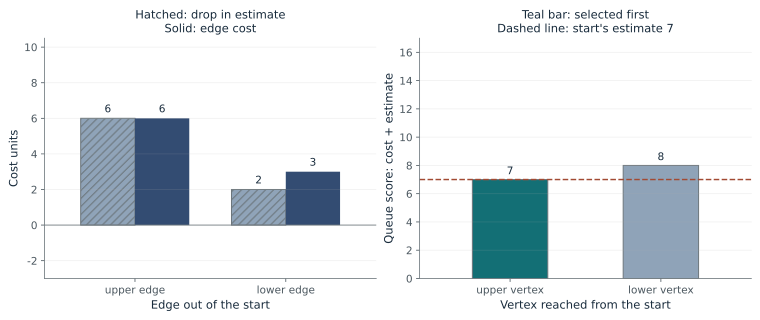

In [14]:
demo_id = 'C09-D03'
demo_controls = {'h_upper': 1, 'h_start': 7}
demo_result = run_demo(9, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Estimate at the upper vertex** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

An estimate must not contradict itself
Controls: {"h_upper": 2, "h_start": 7}
Evidence: constructed teaching example

Calculated quantities:
Upper edge: drop, cost: 5, 6
Lower edge: drop, cost: 2, 3
Consistent on both edges: yes
Scores: upper, lower: 8, 8
Selected first: lower vertex (tie on score, smaller recorded cost)

Worked steps:
1. Upper edge: the estimate goes from 7 to 2, a drop of 5; the edge costs 6.
2. Equation (9.4) in edge form: 7 <= 6 + 2 = 8 is true.
3. Lower edge: 7 <= 3 + 5 = 8 is true.
4. Scores: upper 6 + 2 = 8, lower 3 + 5 = 8.
5. Selected first: lower vertex (tie on score, smaller recorded cost).

Upper edge: 7 <= 6 + 2 = 8 is true, because the estimate drops by 7 - 2 = 5 across an edge costing 6. Lower edge: 7 <= 3 + 5 = 8 is true. The estimate never falls by more than an edge costs, so the fragment is consistent. Selected first: lower vertex (tie on score, smaller recorded cost), with scores 8 (upper) and 8 (lower). No selected score is below the start's estimat

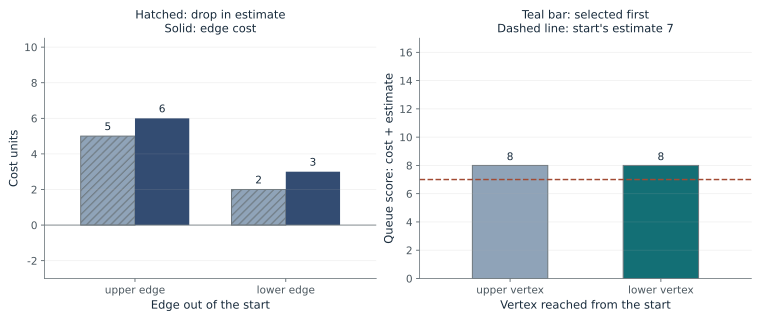

In [15]:
changed_controls = {'h_upper': 2, 'h_start': 7}
changed_demo = run_demo(9, 'C09-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(9, 'C09-D03'):
    state = run_demo(9, 'C09-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "h_upper": 1,
      "h_start": 8
    },
    "metrics": [
      [
        "Upper edge: drop, cost",
        "7, 6"
      ],
      [
        "Lower edge: drop, cost",
        "3, 3"
      ],
      [
        "Consistent on both edges",
        "no (upper edge)"
      ],
      [
        "Scores: upper, lower",
        "7, 8"
      ],
      [
        "Selected first",
        "upper vertex"
      ]
    ]
  },
  {
    "controls": {
      "h_upper": 1,
      "h_start": 7
    },
    "metrics": [
      [
        "Upper edge: drop, cost",
        "6, 6"
      ],
      [
        "Lower edge: drop, cost",
        "2, 3"
      ],
      [
        "Consistent on both edges",
        "yes"
      ],
      [
        "Scores: upper, lower",
        "7, 8"
      ],
      [
        "Selected first",
        "upper vertex"
      ]
    ]
  },
  {
    "controls": {
      "h_upper": 1,
      "h_start": 6
    },
    "metrics": [
      [
        "Upper edge: drop, cost",
        "5,

**Check your understanding:** If the start's estimate is 8 and the upper edge costs 4 instead of 6, what is the smallest estimate at the upper vertex that satisfies consistency?

[Answer and worked reasoning](../solutions/ch09.md#demonstration-3). [Matching browser demonstration](../readers/09-astar-audit/reader.html#C09-D03).

<a id="demo-c09-d04"></a>

### Demonstration 4: What an estimate buys and what it costs

How many expansions does an estimate save compared with guessing zero, and does that pay once computing the estimate costs time?

![Equation 9.2](../assets/math/c87fd983fba2133d2416.svg)

![Equation 9.4](../assets/math/b63e0576c12f18c007c1.svg)

**Symbols and units:** f-hat(v) = g-hat(v) + h-hat(v) must be computed for every vertex the search generates, and computing h-hat is not free. An expansion is one tool call and costs 200 milliseconds (ms); one estimate costs the chosen price. The zero estimate guesses 0 everywhere, costs nothing to compute and is admissible, so it turns A* into uniform-cost search. The informed estimate is the notebook's (3, 4, 1, 0), the two-route graph's exact values at a and b, or the research workflow's structural values (2, 1, 1, 0). Estimates computed is one at the start plus one each time a cheaper route to a vertex is queued.

Time is expansions times 200 ms plus estimates computed times the price. An admissible estimate always returns the same route cost as the zero estimate, and under Theorem 2's conditions it expands a subset of what the zero estimate expands; the saving is the difference. The estimate pays only while that saving, 200 ms per expansion avoided, exceeds what the estimates cost, so the search that expands the fewest vertices can be the slowest to finish.

**Use in this chapter:** Price the estimate in the same unit as the step it is meant to avoid. If scoring a candidate takes a model call, compare it with the tool call, and consider scoring candidates in batches or only when the choice is close.

**Assumptions:** Constant costs per call, and expansion counts that come from these small graphs, not from measurement. Queue work, storage and batching are left out. The 200 ms figure and the 900 ms estimate are the chapter's constructed example; 100 and 400 ms are values chosen for this reader. Theorem 2 compares algorithms with the same information, no ties and a consistent estimate.

**Predict before running:** In the research workflow, how many expansions does the structural estimate save compared with the zero estimate?

**Controls you can change:**

- **Graph and informed estimate:** `graph` accepts 'notebook', 'tworoute', 'workflow'.
- **Time to compute one estimate (ms):** `price` accepts 0, 100, 400, 900.

**Source section:** When the estimate costs more than the vertex.

**Evidence:** constructed teaching example.

Constructed example: the chapter's constructed agent latencies (a 200 ms tool call, a 900 ms estimate) applied to the notebook graph, the chapter's two-route graph and its research workflow, with expansions counted by the chapter's queue rules and checked against the laboratory's A* function.

Prediction choices:

1. Three
2. One
3. None

**Boundary of the conclusion:** Theorem 2 holds only against algorithms with the same information, no ties, and a consistent estimate, which is a narrower class than the phrase optimal search suggests.

**Common wrong turn:** The chapter quotes the paper: the procedure that is optimal in minimum vertices expanded might not be optimal in minimum total resources expended, because the estimate has to be computed whenever a vertex is generated.

What an estimate buys and what it costs
Controls: {"graph": "notebook", "price": 900}
Evidence: constructed teaching example

Calculated quantities:
Expansions, with and without: 2 and 3
Estimates computed: 4
Total time, with and without: 4000 ms and 600 ms
Break-even price per estimate: 50 ms
Verdict: estimate loses

Worked steps:
1. Expansions: 2 with the notebook estimate (exact) (S, B) and 3 with zero (S, A, B).
2. Estimates computed with the estimate: 4 (one at the start, one each time a cheaper route is queued).
3. Time with the estimate = 2 x 200 + 4 x 900 = 4000 ms.
4. Time with zero = 3 x 200 = 600 ms.
5. Expansions saved = 1; break-even price = 1 x 200 / 4 = 50 ms.
6. The estimate loses 3400 ms: the search that expands fewest vertices (2) is not the one that finishes soonest, which is the chapter's point that fewest expansions need not mean least total resources.

Time with the estimate = 2 x 200 + 4 x 900 = 4000 ms; with the zero estimate (free to compute) = 3 x 200 = 600 ms

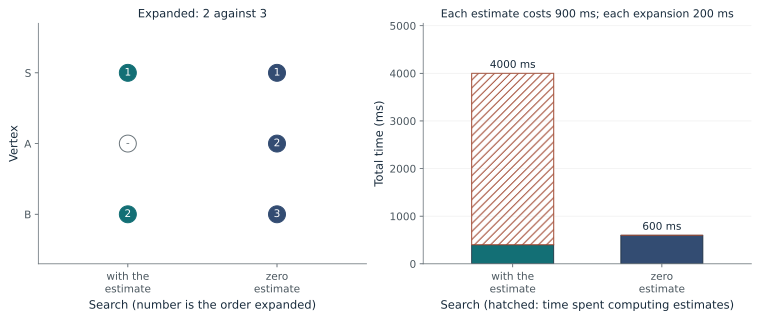

In [17]:
demo_id = 'C09-D04'
demo_controls = {'graph': 'notebook', 'price': 900}
demo_result = run_demo(9, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Graph and informed estimate** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

What an estimate buys and what it costs
Controls: {"graph": "tworoute", "price": 900}
Evidence: constructed teaching example

Calculated quantities:
Expansions, with and without: 2 and 3
Estimates computed: 4
Total time, with and without: 4000 ms and 600 ms
Break-even price per estimate: 50 ms
Verdict: estimate loses

Worked steps:
1. Expansions: 2 with the exact estimate at a and b (s, a) and 3 with zero (s, a, b).
2. Estimates computed with the estimate: 4 (one at the start, one each time a cheaper route is queued).
3. Time with the estimate = 2 x 200 + 4 x 900 = 4000 ms.
4. Time with zero = 3 x 200 = 600 ms.
5. Expansions saved = 1; break-even price = 1 x 200 / 4 = 50 ms.
6. The estimate loses 3400 ms: the search that expands fewest vertices (2) is not the one that finishes soonest, which is the chapter's point that fewest expansions need not mean least total resources.

Time with the estimate = 2 x 200 + 4 x 900 = 4000 ms; with the zero estimate (free to compute) = 3 x 200 = 600 ms

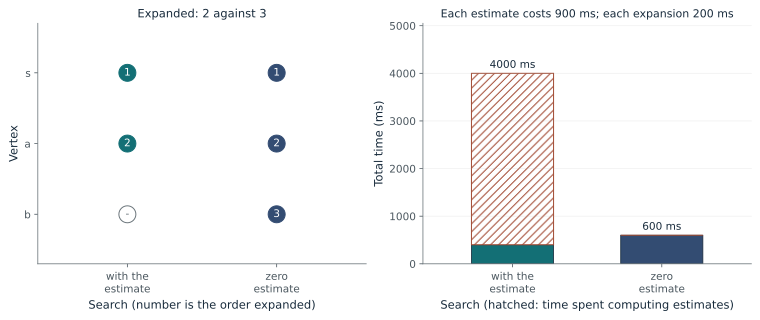

In [18]:
changed_controls = {'graph': 'tworoute', 'price': 900}
changed_demo = run_demo(9, 'C09-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(9, 'C09-D04'):
    state = run_demo(9, 'C09-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "graph": "notebook",
      "price": 0
    },
    "metrics": [
      [
        "Expansions, with and without",
        "2 and 3"
      ],
      [
        "Estimates computed",
        "4"
      ],
      [
        "Total time, with and without",
        "400 ms and 600 ms"
      ],
      [
        "Break-even price per estimate",
        "50 ms"
      ],
      [
        "Verdict",
        "estimate pays"
      ]
    ]
  },
  {
    "controls": {
      "graph": "notebook",
      "price": 100
    },
    "metrics": [
      [
        "Expansions, with and without",
        "2 and 3"
      ],
      [
        "Estimates computed",
        "4"
      ],
      [
        "Total time, with and without",
        "800 ms and 600 ms"
      ],
      [
        "Break-even price per estimate",
        "50 ms"
      ],
      [
        "Verdict",
        "estimate loses"
      ]
    ]
  },
  {
    "controls": {
      "graph": "notebook",
      "price": 400
    },
    "metrics":

**Check your understanding:** In the notebook graph the estimate saves one expansion and needs 4 estimates. What is the most one estimate may cost for the estimate to break even?

[Answer and worked reasoning](../solutions/ch09.md#demonstration-4). [Matching browser demonstration](../readers/09-astar-audit/reader.html#C09-D04).

## Questions

1. What is the default optimal path cost?

2. Which changed heuristic condition fails?

3. What does h=0 produce?

Answers: [separate solutions](../solutions/ch09.md). Try the calculation before opening them.

## Summary

A* combines accumulated cost with a remaining-cost estimate. Its trace is useful only when interpreted with heuristic conditions and computation expense. The default reaches the optimum; the changed heuristic hides the cheaper branch; the transfer case establishes a zero-heuristic baseline. The audit applies to a fully supplied finite graph. It checks a mathematical condition without estimating real-world edge accuracy or granting permission to traverse a route.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-09-astar-audit`](../skills/maa-09-astar-audit/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 9.1

![Equation 9.1](../assets/math/d644bc5f6d134538bbc7.svg)

Equation (9.1) gives the cost of the best route that is forced to pass through a particular vertex.

Add the cheapest way of getting to the vertex to the cheapest way of finishing from it.

LaTeX source, preserved for inspection:

```latex
f(v) \;=\; g(v) \;+\; h(v).
\tag{9.1}
```

### Equation 9.2

![Equation 9.2](../assets/math/c87fd983fba2133d2416.svg)

Equation (9.2) is the computable stand-in for Equation (9.1), and it is what the search actually sorts on.

Add what the search has already spent reaching the vertex to what it guesses finishing will cost.

LaTeX source, preserved for inspection:

```latex
\hat f(v) \;=\; \hat g(v) \;+\; \hat h(v).
\tag{9.2}
```

### Equation 9.3

![Equation 9.3](../assets/math/0363a1925aa679905892.svg)

Equation (9.3) is the condition under which the search cannot be talked out of the best path.

Never guess that finishing will cost more than it actually will.

LaTeX source, preserved for inspection:

```latex
\hat h(v) \;\le\; h(v) \qquad \text{for every vertex } v.
\tag{9.3}
```

### Equation 9.4

![Equation 9.4](../assets/math/b63e0576c12f18c007c1.svg)

Equation (9.4) requires the estimate to be consistent with itself from one vertex to the next.

The true cost of getting from one vertex to another, plus the estimate at the second, must be at least the estimate at the first.

LaTeX source, preserved for inspection:

```latex
h(u,v) \;+\; \hat h(v) \;\ge\; \hat h(u).
\tag{9.4}
```